<a href="https://www.kaggle.com/code/nagajaideepchowdary/nlp-based-customer-support-routing-system?scriptVersionId=348038310" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install transformers==4.41.0 datasets accelerate -q

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# Load the BITEXT dataset
df = pd.read_csv(
    '/kaggle/input/datasets/bitext/bitext-gen-ai-chatbot-customer-support-dataset/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv'
)
 
print("Columns:", df.columns.tolist())
print("Sample:\n", df.head(3))
print("\nUnique categories:", df['category'].unique())
 
# Remap 11 BITEXT categories → 5 departments
LABEL_MAP = {
    'SHIPPING':     'orders',
    'ORDER':        'orders',
    'DELIVERY':     'orders',
    'PAYMENT':      'payments',
    'INVOICE':      'payments',
    'BILLING':      'payments',
    'REFUND':       'returns',
    'CANCELLATION': 'returns',
    'RETURN':       'returns',
    'TECH':         'technical',
    'TECHNICAL':    'technical',
    'ACCOUNT':      'account',
    'CONTACT':      'general',
}
 
df['label'] = df['category'].str.upper().str.strip().map(LABEL_MAP).fillna('general')
print("\nLabel distribution:\n", df['label'].value_counts())
 
# Encode labels as integers (LabelEncoder sorts alphabetically)
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])
CLASSES = list(le.classes_)
print("\nClasses (index order):", CLASSES)
# Expected: ['account', 'general', 'orders', 'payments', 'returns', 'technical']
 
# 80 / 10 / 10 stratified split
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label_id']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label_id']
)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Columns: ['flags', 'instruction', 'category', 'intent', 'response']
Sample:
   flags                                        instruction category  \
0     B   question about cancelling order {{Order Number}}    ORDER   
1   BQZ  i have a question about cancelling oorder {{Or...    ORDER   
2  BLQZ    i need help cancelling puchase {{Order Number}}    ORDER   

         intent                                           response  
0  cancel_order  I've understood you have a question regarding ...  
1  cancel_order  I've been informed that you have a question ab...  
2  cancel_order  I can sense that you're seeking assistance wit...  

Unique categories: ['ORDER' 'SHIPPING' 'CANCEL' 'INVOICE' 'PAYMENT' 'REFUND' 'FEEDBACK'
 'CONTACT' 'ACCOUNT' 'DELIVERY' 'SUBSCRIPTION']

Label distribution:
 label
orders      7952
account     5986
general     5945
payments    3997
returns     2992
Name: count, dtype: int64

Classes (index order): ['account', 'general', 'orders', 'payments', 'returns']

Train

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
 
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 4
LR         = 2e-5
 
# This download requires Internet ON in Kaggle settings
print("Loading tokenizer from HuggingFace Hub...")
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print("Tokenizer loaded OK")
 
class QueryDataset(Dataset):
    def __init__(self, texts, labels):
        # Tokenize entire split at once (faster than per-item)
        self.enc = tokenizer(
            list(texts),
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)
 
    def __len__(self):
        return len(self.labels)
 
    def __getitem__(self, idx):
        return {
            'input_ids':      self.enc['input_ids'][idx],
            'attention_mask': self.enc['attention_mask'][idx],
            'labels':         self.labels[idx]
        }
 
print("Building datasets...")
train_ds = QueryDataset(train_df['instruction'].values, train_df['label_id'].values)
val_ds   = QueryDataset(val_df['instruction'].values,   val_df['label_id'].values)
test_ds  = QueryDataset(test_df['instruction'].values,  test_df['label_id'].values)
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
 
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
 

Loading tokenizer from HuggingFace Hub...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Tokenizer loaded OK
Building datasets...
Train batches: 672 | Val batches: 84


Device: cuda
Training classifier with 5 output classes: ['account', 'general', 'orders', 'payments', 'returns']


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)

Epoch 1 | Step 50/672 | Loss: 1.5892
Epoch 1 | Step 100/672 | Loss: 1.5217
Epoch 1 | Step 150/672 | Loss: 1.2970
Epoch 1 | Step 200/672 | Loss: 1.0281
Epoch 1 | Step 250/672 | Loss: 0.8330
Epoch 1 | Step 300/672 | Loss: 0.6993
Epoch 1 | Step 350/672 | Loss: 0.6025
Epoch 1 | Step 400/672 | Loss: 0.5285
Epoch 1 | Step 450/672 | Loss: 0.4707
Epoch 1 | Step 500/672 | Loss: 0.4243
Epoch 1 | Step 550/672 | Loss: 0.3863
Epoch 1 | Step 600/672 | Loss: 0.3553
Epoch 1 | Step 650/672 | Loss: 0.3287


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


...

Epoch 4 | Step 50/672 | Loss: 0.0004
Epoch 4 | Step 100/672 | Loss: 0.0004
Epoch 4 | Step 150/672 | Loss: 0.0004
Epoch 4 | Step 200/672 | Loss: 0.0004
Epoch 4 | Step 250/672 | Loss: 0.0003
Epoch 4 | Step 300/672 | Loss: 0.0003
Epoch 4 | Step 350/672 | Loss: 0.0003
Epoch 4 | Step 400/672 | Loss: 0.0003
Epoch 4 | Step 450/672 | Loss: 0.0003
Epoch 4 | Step 500/672 | Loss: 0.0003
Epoch 4 | Step 550/672 | Loss: 0.0003
Epoch 4 | Step 600/672 | Loss: 0.0003
Epoch 4 | Step 650/672 | Loss: 0.0003


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



Epoch 4/4 | Avg Loss: 0.0003 | Val Acc: 99.96%


Best Validation Accuracy: 99.96%


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Test Accuracy : 99.93%
Precision     : 0.9993
Recall        : 0.9993
F1 Score      : 0.9993

Classification Report

              precision    recall  f1-score   support

     account     1.0000    1.0000    1.0000       599
     general     1.0000    0.9983    0.9992       594
      orders     0.9975    1.0000    0.9987       796
    payments     1.0000    1.0000    1.0000       400
     returns     1.0000    0.9967    0.9983       299

    accuracy                         0.9993      2688
   macro avg     0.9995    0.9990    0.9992      2688
weighted avg     0.9993    0.9993    0.9993      2688


Confusion Matrix

[[599   0   0   0   0]
 [  0 593   1   0   0]
 [  0   0 796   0   0]
 [  0   0   0 400   0]
 [  0   0   1   0 298]]


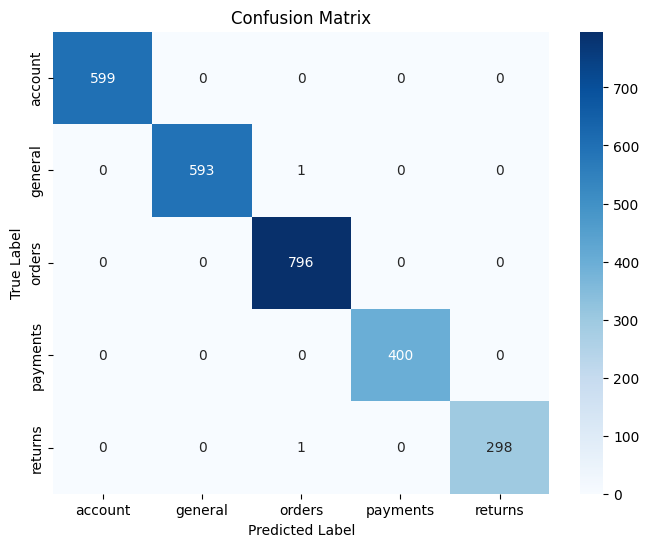

In [4]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

NUM_LABELS = len(CLASSES)
print(f"Training classifier with {NUM_LABELS} output classes: {CLASSES}")

# Load pretrained DistilBERT and replace head with our classifier
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
).to(device)

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.01
)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

best_val_acc = 0.0

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()
    total_loss = 0

    for step, batch in enumerate(train_loader):

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(
                f"Epoch {epoch+1} | Step {step+1}/{len(train_loader)} "
                f"| Loss: {total_loss/(step+1):.4f}"
            )

    avg_loss = total_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for batch in val_loader:

            batch = {k: v.to(device) for k, v in batch.items()}

            preds = model(**batch).logits.argmax(dim=-1)

            correct += (preds == batch["labels"]).sum().item()
            total += len(batch["labels"])

    val_acc = correct / total * 100

    print(
        f"\nEpoch {epoch+1}/{EPOCHS}"
        f" | Avg Loss: {avg_loss:.4f}"
        f" | Val Acc: {val_acc:.2f}%\n"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        model.save_pretrained("/kaggle/working/routeiq-best")
        tokenizer.save_pretrained("/kaggle/working/routeiq-best")

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

# ======================================================
# Final Test Evaluation
# ======================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        preds = outputs.logits.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

# -------------------------
# Metrics
# -------------------------

accuracy = accuracy_score(all_labels, all_preds)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="weighted"
)

print("=" * 60)
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print("=" * 60)

# -------------------------
# Classification Report
# -------------------------

print("\nClassification Report\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=CLASSES,
        digits=4
    )
)

# -------------------------
# Confusion Matrix
# -------------------------

cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix\n")
print(cm)

# -------------------------
# Confusion Matrix Heatmap
# -------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [5]:
import json, os, shutil
 
SAVE_PATH = "/kaggle/working/routeiq-model"
 
# Copy best checkpoint to final output folder
if os.path.exists('/kaggle/working/routeiq-best'):
    shutil.copytree('/kaggle/working/routeiq-best', SAVE_PATH, dirs_exist_ok=True)
else:
    # Fallback: save current model state
    os.makedirs(SAVE_PATH, exist_ok=True)
    model.save_pretrained(SAVE_PATH)
    tokenizer.save_pretrained(SAVE_PATH)
 
# Save label index → department name mapping
# This is what the FastAPI backend uses to decode predictions
labels_dict = {str(i): label for i, label in enumerate(CLASSES)}
with open(f"{SAVE_PATH}/labels.json", "w") as f:
    json.dump(labels_dict, f, indent=2)
 
print("labels.json contents:", labels_dict)
print("\nSaved files:", sorted(os.listdir(SAVE_PATH)))
 
# Expected output:
# config.json
# labels.json
# model.safetensors   (~260 MB)
# tokenizer.json
# tokenizer_config.json
# vocab.txt
 
print("\n✓ Done! Go to Output tab → download routeiq-model/ as zip")

labels.json contents: {'0': 'account', '1': 'general', '2': 'orders', '3': 'payments', '4': 'returns'}

Saved files: ['config.json', 'labels.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']

✓ Done! Go to Output tab → download routeiq-model/ as zip


In [6]:
import shutil, os
 
# Zip routeiq-model/ → routeiq-model.zip
shutil.make_archive(
    '/kaggle/working/routeiq-model',  # output zip path (no .zip, it adds it)
    'zip',                             # format
    '/kaggle/working',                 # root dir
    'routeiq-model'                    # folder to zip
)
 
size = os.path.getsize('/kaggle/working/routeiq-model.zip') / (1024*1024)
print(f"✓ routeiq-model.zip created — {size:.1f} MB")
print("Now go to Output tab → click routeiq-model.zip → Download")

✓ routeiq-model.zip created — 235.9 MB
Now go to Output tab → click routeiq-model.zip → Download
